In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
luccaoliveiraseixas_lidar_dataset_path = kagglehub.dataset_download('luccaoliveiraseixas/lidar-dataset-3')

print('Data source import complete.')


Using Colab cache for faster access to the 'lidar-dataset-3' dataset.
Data source import complete.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
from tqdm import tqdm


In [ ]:
print(f"The base path for the downloaded dataset is: {luccaoliveiraseixas_lidar_dataset_path}")
DATASET_DIR = Path(luccaoliveiraseixas_lidar_dataset_path) / "dataset_lidar_pose"
print(f"The complete dataset directory being used is: {DATASET_DIR}")

The base path for the downloaded dataset is: /kaggle/input/lidar-dataset-3
The complete dataset directory being used is: /kaggle/input/lidar-dataset-3/dataset_lidar_pose


In [ ]:
class LidarPoseLight(nn.Module):
    def __init__(self, T, n_rays, n_out=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, (3, 5), padding=(1, 2)),
            nn.ReLU(),

            nn.Conv2d(16, 32, (3, 5), padding=(1, 2)),
            nn.ReLU(),
            nn.MaxPool2d((1, 4)),

            nn.Conv2d(32, 32, (3, 5), padding=(1, 2)),
            nn.ReLU(),
            nn.MaxPool2d((1, 4)),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, T, n_rays)
            flat_dim = self.features(dummy).view(1, -1).size(1)

        self.head = nn.Sequential(
            nn.Linear(flat_dim + 2, 128),  # + yaw (cos, sin)
            nn.ReLU(),
            nn.Linear(128, n_out)
        )

    def forward(self, x, yaw):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = torch.cat([x, yaw], dim=1)
        return self.head(x)


In [ ]:
T = 3
BATCH_SIZE = 64
EPOCHS = 60
LR = 4e-3
LIDAR_RANGE = 5.5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
class LidarSeqCnnDataset(Dataset):
    def __init__(self, files, T=3, augment=False):
        self.files = sorted(files)
        self.T = T
        self.augment = augment

    def __len__(self):
        return len(self.files) - self.T + 1

    def __getitem__(self, idx):
        scans = []

        shift = None
        if self.augment:
            sample = np.load(self.files[idx])
            N = sample["lidar"].shape[0]
            shift = np.random.randint(0, N)

        # ---------- sequência temporal ----------
        for k in range(self.T):
            d = np.load(self.files[idx + k])
            scan = d["lidar"]  # já normalizado [0,1]

            if shift is not None:
                scan = np.roll(scan, shift)

            scans.append(scan)

        # [1, T, N_rays]
        X = torch.tensor(
            np.stack(scans),
            dtype=torch.float32
        ).unsqueeze(0)

        # ---------- label no tempo t ----------
        d_last = np.load(self.files[idx + self.T - 1])

        pose_xy = torch.tensor(d_last["pose_xy"], dtype=torch.float32)
        yaw = torch.tensor(d_last["yaw"], dtype=torch.float32)

        return X, pose_xy, yaw


In [ ]:
import random
import numpy as np
from torch.utils.data import DataLoader

random.seed(42)
np.random.seed(42)

files = sorted(DATASET_DIR.glob("*.npz"))
n = len(files)

n_effective = n - T + 1

split = int(0.8 * n_effective)

train_files = files[:split + T - 1]
val_files   = files[split:]


train_ds = LidarSeqCnnDataset(
    train_files,
    T=T,
    augment=True
)

val_ds = LidarSeqCnnDataset(
    val_files,
    T=T,
    augment=False
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=12,
    pin_memory=True,
    persistent_workers=True
)



In [ ]:

N_RAYS = train_ds[0][0].shape[-1]

model = LidarPoseLight(T=T, n_rays=N_RAYS, n_out=2).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


In [ ]:
def eval_pos_error(pred, gt):
    # pred, gt: [B, 2]
    return torch.linalg.norm(pred - gt, dim=1)  # [B]

def loss_fn(pred, gt):
    # pred: [B,2], gt: [B,2]
    return torch.nn.functional.smooth_l1_loss(pred, gt)




In [ ]:
PATIENCE = 10
best_val = float("inf")
best_state = None
history = {"train": [], "val": [], "pos_err": []}
epochs_no_improve = 0
for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = 0.0

    for X, pose_xy, yaw in train_loader:
        X = X.to(DEVICE)              # [B, 1, T, 360]
        pose_xy = pose_xy.to(DEVICE)  # [B, 2]
        yaw = yaw.to(DEVICE)          # [B, 2]

        optimizer.zero_grad()
        pred = model(X, yaw)
        loss = loss_fn(pred, pose_xy)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item() * X.size(0)

    tr_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    total_err = 0.0

    with torch.no_grad():
        for X, pose_xy, yaw in val_loader:
            X = X.to(DEVICE)
            pose_xy = pose_xy.to(DEVICE)
            yaw = yaw.to(DEVICE)

            pred = model(X, yaw)
            val_loss += loss_fn(pred, pose_xy).item() * X.size(0)
            total_err += eval_pos_error(pred, pose_xy).sum().item()

    val_loss /= len(val_loader.dataset)
    mean_err = total_err / len(val_loader.dataset)

    history["train"].append(tr_loss)
    history["val"].append(val_loss)
    history["pos_err"].append(mean_err)

    scheduler.step(val_loss)
    
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(best_state, "lidar_gps_best.pth")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"⏹ Early stopping na época {epoch}")
            break

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={tr_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"pos_err={mean_err:.3f} m | "
        f"LR={optimizer.param_groups[0]['lr']:.6f}"
    )


Epoch 01 | train_loss=0.1426 | val_loss=0.0343 | pos_err=0.309 m | LR=0.004000
Epoch 02 | train_loss=0.0319 | val_loss=0.0187 | pos_err=0.230 m | LR=0.004000
Epoch 03 | train_loss=0.0233 | val_loss=0.0202 | pos_err=0.239 m | LR=0.004000
Epoch 04 | train_loss=0.0203 | val_loss=0.0175 | pos_err=0.226 m | LR=0.004000
Epoch 05 | train_loss=0.0181 | val_loss=0.0156 | pos_err=0.212 m | LR=0.004000
Epoch 06 | train_loss=0.0175 | val_loss=0.0149 | pos_err=0.207 m | LR=0.004000
Epoch 07 | train_loss=0.0158 | val_loss=0.0126 | pos_err=0.189 m | LR=0.004000
Epoch 08 | train_loss=0.0148 | val_loss=0.0116 | pos_err=0.180 m | LR=0.004000
Epoch 09 | train_loss=0.0146 | val_loss=0.0111 | pos_err=0.177 m | LR=0.004000
Epoch 10 | train_loss=0.0142 | val_loss=0.0133 | pos_err=0.191 m | LR=0.004000
Epoch 11 | train_loss=0.0135 | val_loss=0.0193 | pos_err=0.230 m | LR=0.004000
Epoch 12 | train_loss=0.0128 | val_loss=0.0132 | pos_err=0.195 m | LR=0.002000
Epoch 13 | train_loss=0.0083 | val_loss=0.0084 | pos

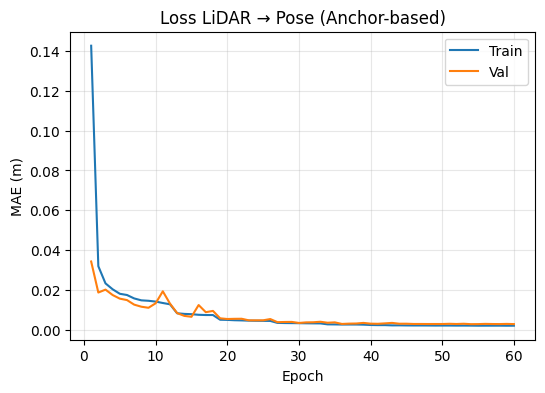

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train"], label="Train")
plt.plot(epochs, history["val"], label="Val")

plt.xlabel("Epoch")
plt.ylabel("MAE (m)")
plt.title("Loss LiDAR → Pose")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



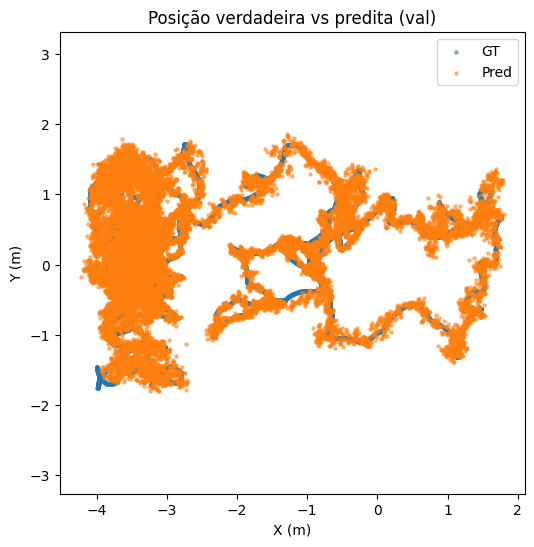

In [ ]:
model.eval()
pred_x, pred_y = [], []
true_x, true_y = [], []

with torch.no_grad():
    for X, y, yaw in val_loader:  # <- CORRETO: y = pose_xy
        X   = X.to(DEVICE)
        y   = y.to(DEVICE)
        yaw = yaw.to(DEVICE)      # [B, 2]

        pred = model(X, yaw)

        pred_x.extend(pred[:, 0].cpu().numpy())
        pred_y.extend(pred[:, 1].cpu().numpy())
        true_x.extend(y[:, 0].cpu().numpy())
        true_y.extend(y[:, 1].cpu().numpy())

plt.figure(figsize=(6, 6))
plt.scatter(true_x, true_y, s=5, label="GT", alpha=0.5)
plt.scatter(pred_x, pred_y, s=5, label="Pred", alpha=0.5)
plt.axis("equal")
plt.legend()
plt.title("Posição verdadeira vs predita (val)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()


In [ ]:
model.eval()
errors = []

with torch.no_grad():
    for X, pose_xy, yaw in val_loader:
        X = X.to(DEVICE)
        pose_xy = pose_xy.to(DEVICE)
        yaw = yaw.to(DEVICE)  # deve ter shape [batch, 2]

        pred = model(X, yaw)  # passa X e yaw
        err = torch.norm(pred - pose_xy, dim=1)  # erro euclidiano
        errors.extend(err.cpu().numpy())


In [ ]:

errors = np.array(errors)

print("Mediana:", np.median(errors))
print("Média:", np.mean(errors))
print("Desvio padrão:", np.std(errors))
print("Percentis 25/50/75:", np.percentile(errors, [25,50,75]))
print("Máximo:", errors.max())
print("Mínimo:", errors.min())


Mediana: 0.06279318
Média: 0.07681508
Desvio padrão: 0.07481572
Percentis 25/50/75: [0.03931866 0.06279318 0.09451011]
Máximo: 1.3902568
Mínimo: 0.00023594756


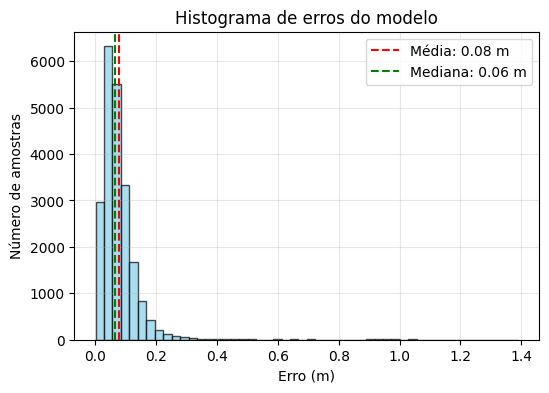

In [ ]:
errors = np.array(errors)

mean_err = errors.mean()
median_err = np.median(errors)

plt.figure(figsize=(6, 4))
plt.hist(errors, bins=50, color='skyblue', edgecolor='k', alpha=0.7)

plt.axvline(mean_err, color='r', linestyle='--', label=f'Média: {mean_err:.2f} m')
plt.axvline(median_err, color='g', linestyle='--', label=f'Mediana: {median_err:.2f} m')

plt.xlabel("Erro (m)")
plt.ylabel("Número de amostras")
plt.title("Histograma de erros do modelo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()